## PaleoExfiltration Model Code ##

### Load in packages to run hydromechanical model and plot ###

In [29]:
# Load in necessary packages 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as spr
from scipy.sparse.linalg import inv
from pyproj import Proj, transform
import cartopy.feature as cfeature

### Load in thickness-time series data and determine the duration for each site ###

In [50]:
# Loading in the interpolated data frame produced in the 'BayesianSplineandSensitivityTest.ipynb'
file_path ='thicknesstimeserieslowerCIfinal.csv' # or could be 'thicknesstimeseriesupperCIfinal.csv' or 'thicknesstimeserieslowerCIfinal.csv'
interpolated_df = pd.read_csv(file_path)

# Calculate the duration for each site
duration_tf = interpolated_df.groupby('Site').agg(
    Start_Age=('Age', 'max'),
    End_Age=('Age', 'min'),
    Duration=('Age', lambda x: x.max() - x.min())
).reset_index()

# Display the first few rows of the duration data; 'Start_Age' should be 20,000 and 'End_Age' should be 0
duration_tf

,Site,Start_Age,End_Age,Duration
0,4,20000,0,20000
1,7,20000,0,20000
2,11,20000,0,20000
3,15,20000,0,20000
4,17,20000,0,20000
5,21,20000,0,20000
6,22,20000,0,20000
7,24,20000,0,20000
8,27,20000,0,20000
9,28,20000,0,20000


## Count the number of unique sites in the dataset

In [51]:
num_unique_sites = interpolated_df['Site'].nunique()
num_unique_sites

60

## Parameters

In [52]:
# This code block is helpful for looking at the thickness-time series of a specific site

# Set the site number
site = 129

# Extract data for the selected site
site_data = interpolated_df[interpolated_df['Site'] == site].copy()

# Sort from oldest to youngest
# Age is assumed to be years before present
site_data = site_data.sort_values('Age',ascending=False).reset_index(drop=True)

# Extract age and thickness
age = site_data['Age'].values
thickness = site_data['Thickness'].values

# Extract latitude and longitude
site_lat = site_data['Latm'].iloc[0]
site_lon = site_data['Lonm'].iloc[0]

## Specify a site number to produce a thickness vs elevation vs time plot for (optional)

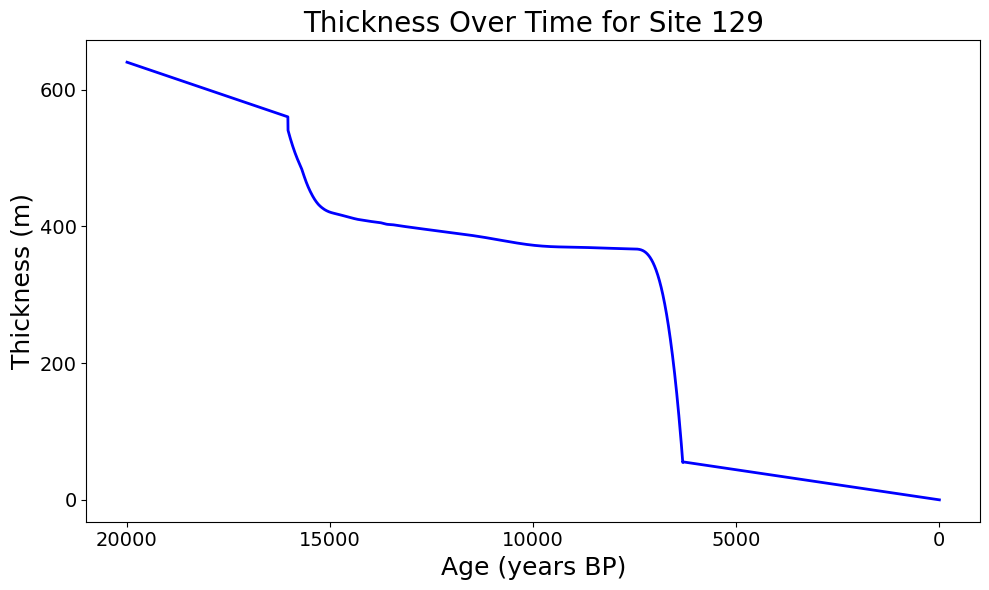

In [53]:
# Plot the reconstructed thickness history for the selected site

plt.figure(figsize=(10, 6))
plt.plot(site_data['Age'],site_data['Thickness'],color='blue',linewidth=2)
plt.xlabel('Age (years BP)',fontsize=18)
plt.ylabel('Thickness (m)',fontsize=18)
plt.title(f'Thickness Over Time for Site {site}',fontsize=20)

# Show oldest age on the left and present on the right
plt.gca().invert_xaxis()

# Customize ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Reduce number of ticks
plt.locator_params(axis='x',nbins=5)
plt.locator_params(axis='y',nbins=5)
plt.tight_layout()
plt.show()

## Load in necessary packages

In [54]:
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import cmocean
import scipy.io as sio
import geopandas as gpd
import rioxarray
import zipfile

## Grids and pre-allocation (for the numerical solver)

In [55]:
# # Define the length of the domain (L) in meters. In this case, it's 40 km (40,000 meters).
# L = 40e3

# # Set the number of grid points (nx) to 1001
# nx = int(1e3 + 1) # Make it smaller to make the grid coarser 

# # Generate a linearly spaced array (x) from 0 to L, with nx points.
# # This array represents the spatial coordinates across the domain.
# x = np.linspace(0, L, num=nx)

# # Calculate the grid spacing (dx) as the difference between consecutive points in the x array.
# dx = x[1] - x[0]

# # Set a diffusion coefficient (C_D) to 1, which is a dimensionless parameter used in the time step calculation.
# C_D = 1

# # Calculate the time step (dt) based on the grid spacing (dx) and a given diffusion constant (D).
# # The time step is determined by the stability criterion for the diffusion equation.
# dt = (dx**2) * C_D / D # Make the time step longer by changing nx.

# # Define the total simulation time (tf) in seconds
# tf = (site_data['Age'].max() - site_data['Age'].min())#How many years we want the simulation to be 

# # Calculate the total number of time steps (nt) based on the total time (tf) and the time step (dt).
# # The result is rounded and then increased by 1 to account for the initial time step.
# #nt = int(np.round(tf / dt) + 1)
# nt = len(site_data)

# # Generate a linearly spaced array (t) from 0 to tf, with nt points.
# # This array represents the time steps across the entire simulation period.
# #t = np.linspace(0, tf, num=nt) # Vector that goes over the years you want to simulate. 
# t = site_data['Age'].values

# # Initialize the hydraulic pressure head (h) within the sediment.
# # The initial head (h_init) is scaled by the ratio of ice density (rhoi) to water density (rhow)
# # and is uniformly applied across the entire domain (nx points).
# h = h_init * (rhoi / rhow) * np.ones(nx)

# # Create an array (h_all) to store the hydraulic pressure head values at each time step for the entire domain.
# # The array has dimensions [nx, int(nt/intSave)+1], where intSave is a variable controlling the frequency of saving data.
# h_all = np.zeros([nx, int(nt/intSave) + 1])

# # Store the initial hydraulic pressure head (h) in the first column of h_all.
# h_all[:, 0] = h

## Solve with Crank-Nicolson method (for the numerical solution)

In [56]:
# # Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the left-side matrix (Ml)
# Mld = np.zeros([3,nx])

# # Set the first and third rows of the matrix to be -0.5*C_D for all columns
# Mld[0, :] = -0.5 * C_D * np.ones(nx)  # Upper diagonal
# Mld[2, :] = -0.5 * C_D * np.ones(nx)  # Lower diagonal

# # Set the second row of the matrix to be (1+C_D) for all columns
# Mld[1, :] = (1 + C_D) * np.ones(nx)  # Main diagonal

# # Create a sparse matrix (Ml) using the diagonals in Mld with offsets -1, 0, and 1
# Ml = spr.spdiags(Mld, [-1, 0, 1], nx, nx)

# # Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
# Ml = spr.csc_matrix(Ml)

# # Modify specific elements in the sparse matrix to enforce boundary conditions
# Ml[-1, -1] = 1 + 0.5 * C_D  # Adjust the last element on the main diagonal
# Ml[0, 1] = 0  # Set the first off-diagonal element to zero
# Ml[0, 0] = 1  # Set the first element on the main diagonal to one

# # Compute the inverse of the left-side matrix (Ml)
# iMl = inv(Ml)

# # Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the right-side matrix (Mr)
# Mrd = np.zeros([3, nx])

# # Set the first and third rows of the matrix to be 0.5*C_D for all columns
# Mrd[0, :] = 0.5 * C_D * np.ones(nx)  # Upper diagonal
# Mrd[2, :] = 0.5 * C_D * np.ones(nx)  # Lower diagonal

# # Set the second row of the matrix to be (1-C_D) for all columns
# Mrd[1, :] = (1 - C_D) * np.ones(nx)  # Main diagonal

# # Create a sparse matrix (Mr) using the diagonals in Mrd with offsets -1, 0, and 1
# Mr = spr.spdiags(Mrd, [-1, 0, 1], nx, nx)

# # Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
# Mr = spr.csc_matrix(Mr)

# # Modify specific elements in the sparse matrix to enforce boundary conditions
# Mr[-1, -1] = 1 - 0.5 * C_D  # Adjust the last element on the main diagonal
# Mr[0, 1] = 0  # Set the first off-diagonal element to zero
# Mr[0, 0] = 1  # Set the first element on the main diagonal to one

In [57]:
# # Loop through each time step from 0 to nt-2 (nt-1 in zero-indexed Python)
# for k in np.arange(nt-1):
#     # Create a copy of the current ice thickness (h) and reshape it into a column vector (nx, 1)
#     hm = h
#     hm.shape = (nx, 1)

#     # Apply boundary condition: Set the surface height at the first grid point to the surface height at this time step
#     # adjusted by the ratio of ice density (rhoi) to water density (rhow)
#     h[0] = hbc_sfc[k] * (rhoi / rhow)

#     # Initialize a source vector (Svec) with zeros, used to apply the source term from the thinning rate
#     Svec = np.zeros([nx, 1])

#     # Apply the source term (related to thinning rate) to the interior points of the grid
#     Svec[1:-2] = dt * xi * (rhoi / rhow) * dhdt[k]

#     # Compute the new ice thickness (hnew) by applying the inverse of the left-side matrix (iMl)
#     # to the matrix-vector product of the right-side matrix (Mr) and the current ice thickness (hm), 
#     # and adding the source term vector (Svec)
#     hnew = iMl.dot(Mr.dot(hm) + Svec)

#     # Save the computed ice thickness at intervals specified by intSave
#     if k % intSave == 0:
#         h_all[:, int(k/intSave)] = np.transpose(hnew)

#     # Update the ice thickness (h) to the newly computed values for the next iteration
#     h = hnew

## Calculate and plot exfiltration prediction

In [70]:
# Constants
year = 3600 * 24 * 365  # seconds in a year
rhoi = 920  # density of glacier ice (kg/m3)
rhow = 1000  # density of water (kg/m3)
g = 9.81  # acceleration due to gravity (m/s2)
mu_w = 1e-3  # viscosity of water (Pa*s)
perm = 1e-15 # permeability (m^2)
K_t = perm * rhow * g / mu_w  # hydraulic conductivity (m/s)
S = 1e-4  # sediment specific storage capacity (m-1)
xi = 0.2  # Skempton's constant (dimensionless)


# Convert the age/thickness history into forward time and piecewise-constant thinning rates
def interval_rates(age, thickness):
    age = np.asarray(age, dtype=float)
    thickness = np.asarray(thickness, dtype=float)

    # Sort oldest to youngest
    order = np.argsort(-age)
    age = age[order]
    thickness = thickness[order]

    # Convert years before present to forward time in seconds
    t = (age[0] - age) * year

    # Positive rate = thinning; negative rate = thickening
    R = -np.diff(thickness) / np.diff(t)
    return t, R


# Calculate exfiltration using superposition of all previous thinning/thickening intervals
def exfiltration(age, thickness, K_t, S, xi, rhoi=920.0, rhow=1000.0, t_eval=None):

    t, R = interval_rates(age, thickness)

    if t_eval is None:
        t_out = t
    else:
        t_out = np.asarray(t_eval, dtype=float)

    # Constant analytical prefactor
    C = ((1.0 - xi)* (rhoi / rhow)* np.sqrt(K_t * S / np.pi))

    # Time elapsed since each interval started
    lag_on = np.maximum(t_out[:, None] - t[None, :-1],0.0)

    # Time elapsed since each interval ended
    lag_off = np.maximum(t_out[:, None] - t[None, 1:],0.0)

    # Finite-interval analytical response
    W = 2.0 * (np.sqrt(lag_on)- np.sqrt(lag_off))

    # Superposition of all interval contributions
    q = C * (W @ R)

    return t_out, q

# Ensure selected site is ordered oldest to youngest
site_data = site_data.sort_values('Age',ascending=False).reset_index(drop=True)

# Calculate the exfiltration rate for the selected site
t_site, exfil_analytic = exfiltration(
    site_data['Age'].values,
    site_data['Thickness'].values,
    K_t,
    S,
    xi,
    rhoi=rhoi,
    rhow=rhow
)

# Convert from m/s to mm/yr
exfil_value = exfil_analytic * year * 1000

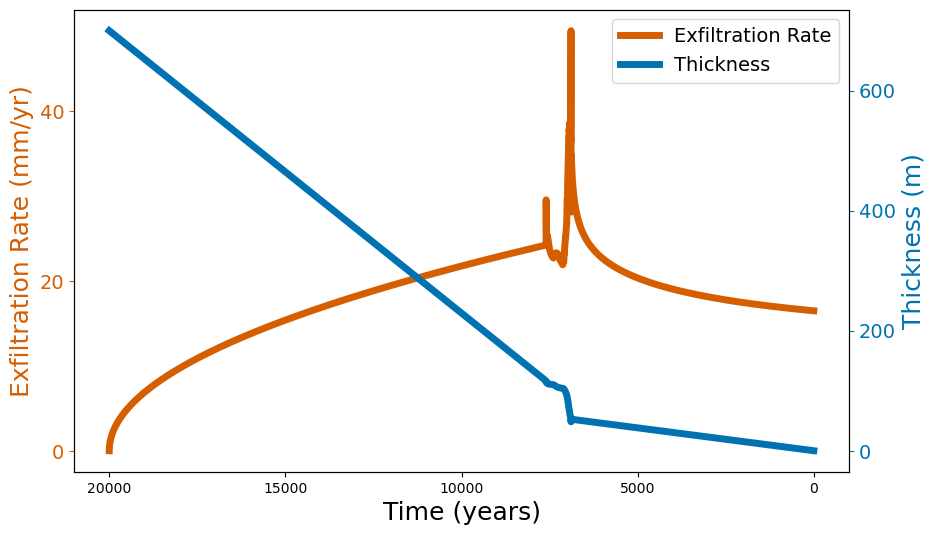

In [71]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Set a consistent line width
line_width = 5

# Plot the exfiltration rate on the primary y-axis
line1, = ax1.plot(site_data['Age'], exfil_value, '-', color='#D55E00', label='Exfiltration Rate', linewidth=line_width)
ax1.set_xlabel('Time (years)', fontsize=18)
ax1.set_ylabel('Exfiltration Rate (mm/yr)', fontsize=18, color='#D55E00')
ax1.tick_params(axis='y', labelsize=14, colors='#D55E00')
ax1.invert_xaxis()  # Invert x-axis so that time decreases to the right
ax1.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
ax1.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Create a secondary y-axis for thickness
ax2 = ax1.twinx()
line2, = ax2.plot(site_data['Age'], site_data['Thickness'], color='#0072B2', label='Thickness', linewidth=line_width)
ax2.set_ylabel('Thickness (m)', fontsize=18, color='#0072B2')
ax2.tick_params(axis='y', labelsize=14, colors='#0072B2')
ax2.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Combine legends and place it in the upper right
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

# Set title
plt.title(f'', fontsize=15)
#plt.savefig("exfiltration_thickness_plot.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

## Storing paleoexfiltration values

In [72]:
# Calculate and store exfiltration values for all the sites

# Initialize an empty DataFrame to store exfiltration values
time_steps = interpolated_df['Age'].unique()
exfiltration_df = pd.DataFrame(
    index=interpolated_df.index,
    columns=['Site', 'Age', 'Latitude', 'Longitude', 'Exfiltration (mm/yr)']
)

# Ensure exfil_value is reset before looping over sites
exfil_value = None

for site in interpolated_df['Site'].unique():
    site_data = interpolated_df[interpolated_df['Site'] == site].copy()

    # Sort from oldest to youngest for superposition
    site_data = site_data.sort_values('Age', ascending=False)

    # Calculate exfiltration using the full loading history
    t_site, exfil_analytic = exfiltration(
        site_data['Age'].values,
        site_data['Thickness'].values,
        K_t,
        S,
        xi,
        rhoi=rhoi,
        rhow=rhow
    )

    # Convert from m/s to mm/yr
    exfil_value = exfil_analytic * year * 1000

    # Extract latitude and longitude
    site_lat = site_data['Latm'].iloc[0]
    site_long = site_data['Lonm'].iloc[0]

    # Store values in DataFrame
    exfiltration_df.loc[site_data.index, 'Site'] = site
    exfiltration_df.loc[site_data.index, 'Age'] = site_data['Age']
    exfiltration_df.loc[site_data.index, 'Latitude'] = site_lat
    exfiltration_df.loc[site_data.index, 'Longitude'] = site_long
    exfiltration_df.loc[site_data.index, 'Exfiltration (mm/yr)'] = exfil_value

# Convert columns to appropriate data types
exfiltration_df['Site'] = exfiltration_df['Site'].astype(str)
exfiltration_df['Age'] = exfiltration_df['Age'].astype(float)
exfiltration_df['Latitude'] = exfiltration_df['Latitude'].astype(float)
exfiltration_df['Longitude'] = exfiltration_df['Longitude'].astype(float)
exfiltration_df['Exfiltration (mm/yr)'] = exfiltration_df['Exfiltration (mm/yr)'].astype(float)

# Save to CSV
exfiltration_df.to_csv('paleoexfiltrationperm15lowerCIfinal.csv', index=False)